analisis gap hasil kalibrasi

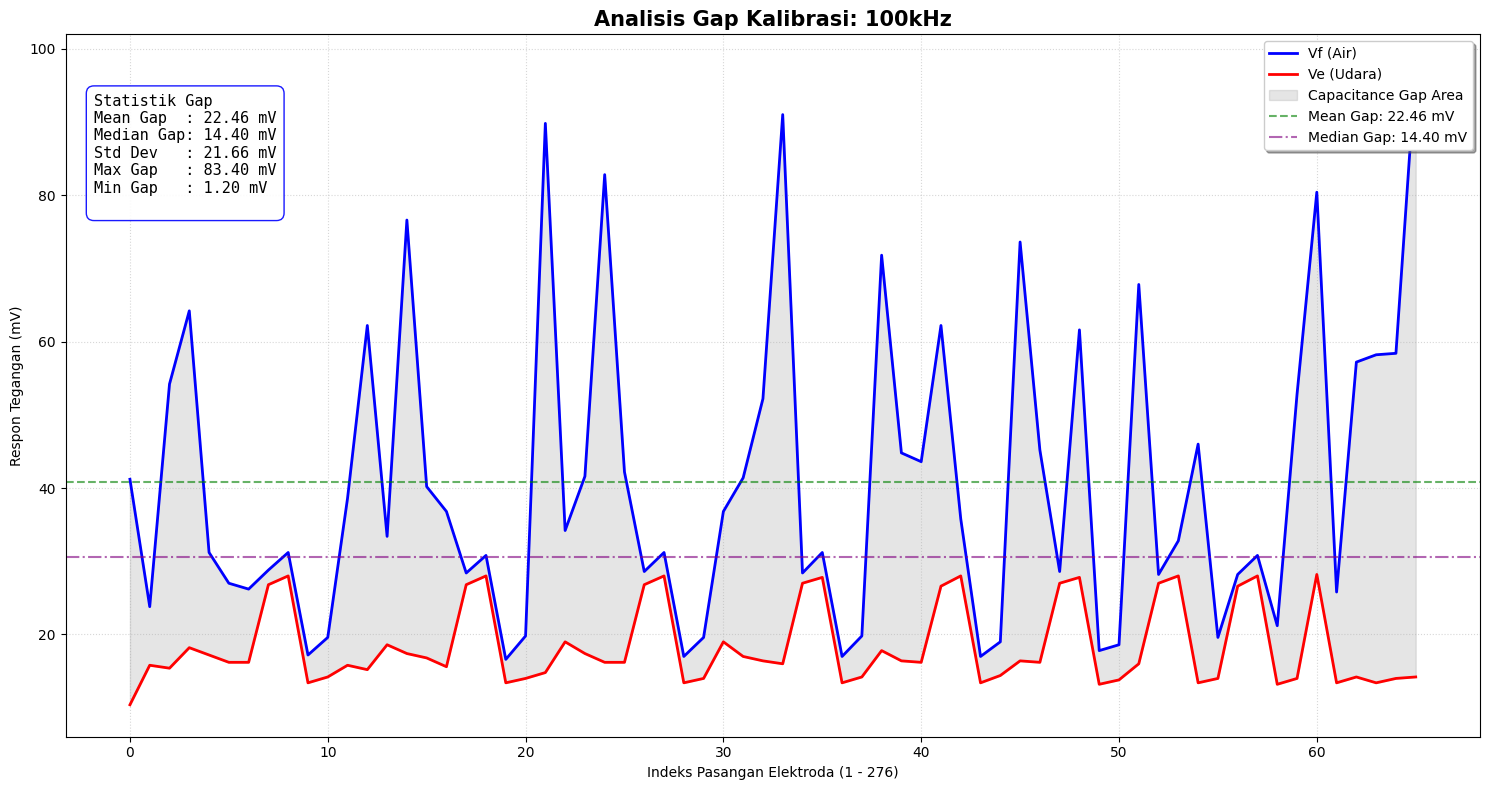

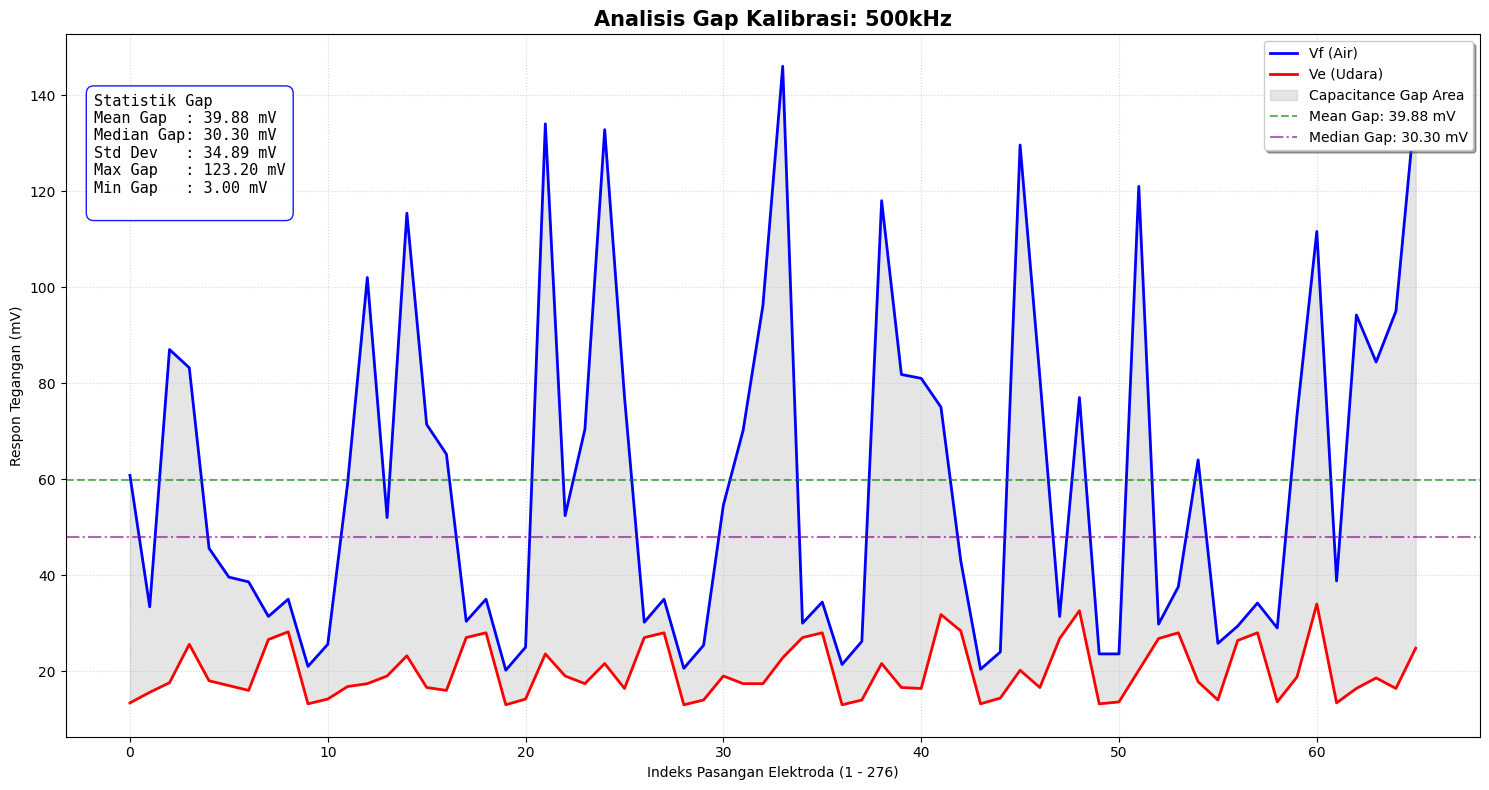

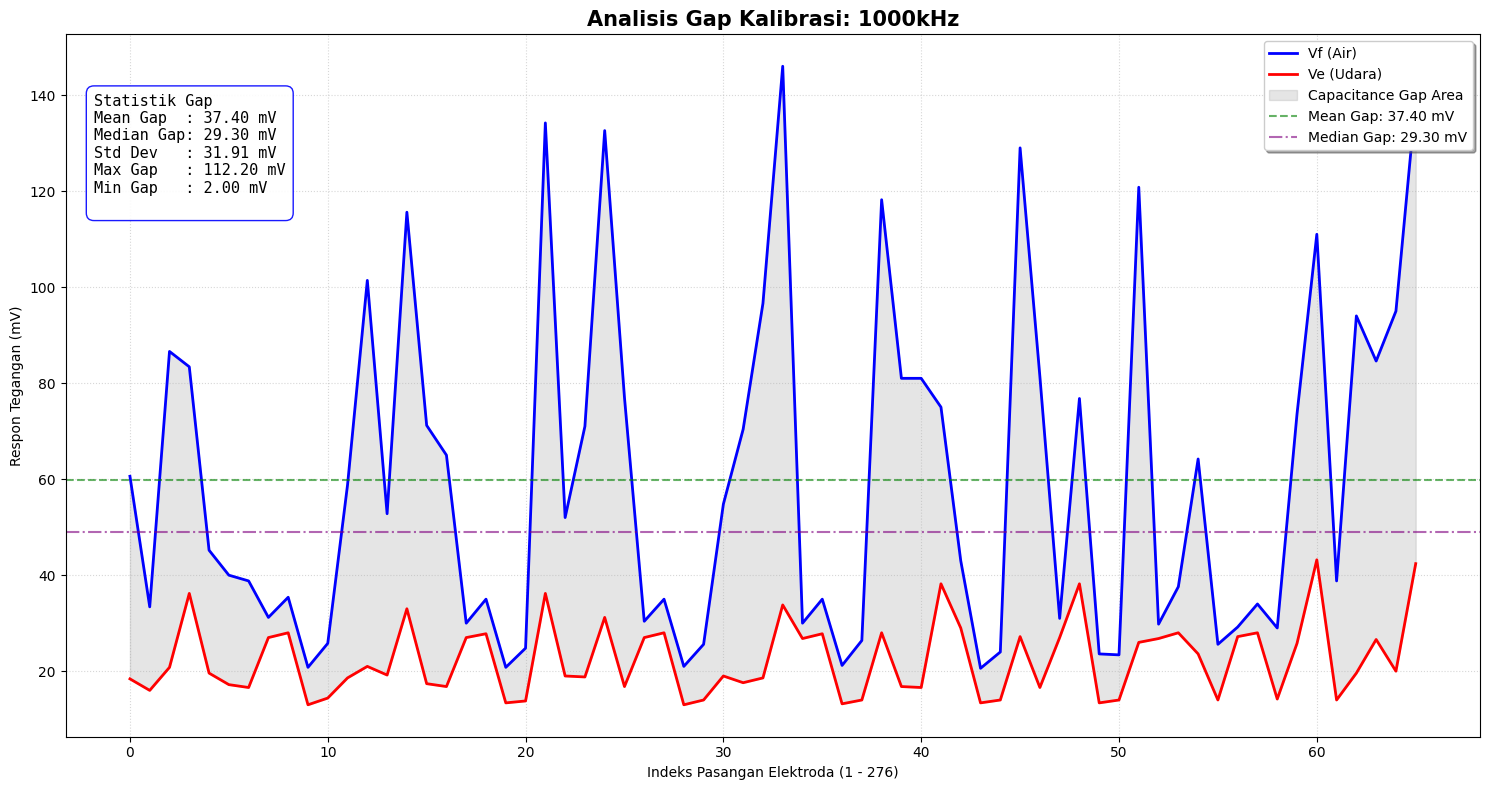

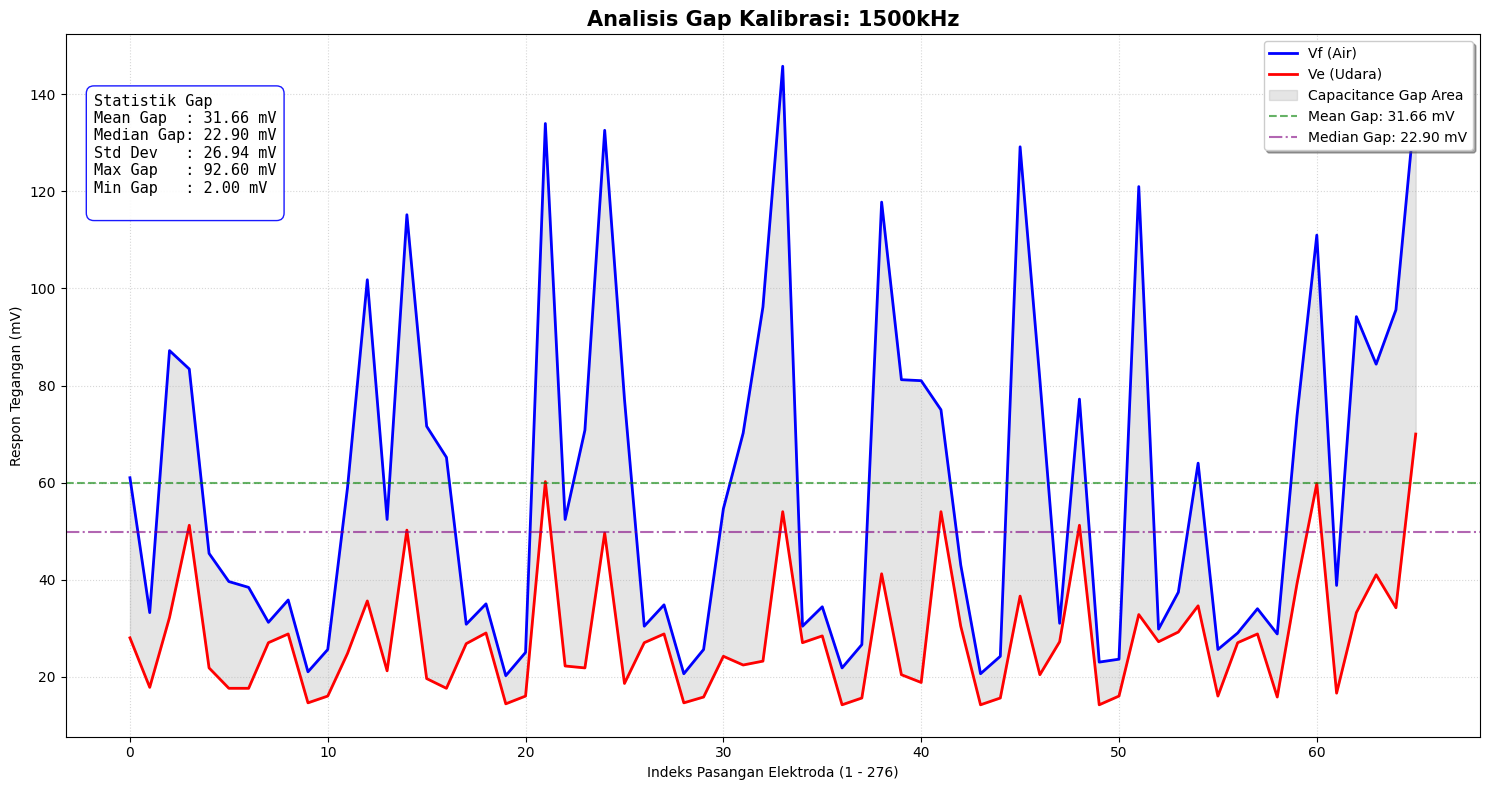

In [7]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_enhanced_gap_analysis(file_path):
    try:
        # 1. Loading Data
        mat_data = scipy.io.loadmat(file_path)
        freqs_raw = mat_data['LS_FREQS'].flatten()
        ve_all_freq = np.mean(mat_data['Ve_kalibrasi'], axis=1)
        vf_all_freq = np.mean(mat_data['Vf_kalibrasi'], axis=1)
        
        indices = np.arange(ve_all_freq.shape[0])

        for i, freq_val in enumerate(freqs_raw):
            current_freq_label = f"{freq_val:.0f}kHz"
            ve = ve_all_freq[:, i]
            vf = vf_all_freq[:, i]
            gap = vf - ve
            
            # --- PERHITUNGAN STATISTIK GAP ---
            mean_gap = np.mean(gap)
            median_gap = np.median(gap) 
            std_gap = np.std(gap)
            max_gap = np.max(gap)
            min_gap = np.min(gap)
            #dead_indices = np.where(gap < 5.0)[0]

            # 2. Plotting
            plt.figure(figsize=(15, 8))
            
            # Garis Vf dan Ve
            plt.plot(indices, vf, label='Vf (Air)', color= 'blue', linewidth=2)
            plt.plot(indices, ve, label='Ve (Udara)', color= 'red', linewidth=2)
            
            # Arsir Gap
            plt.fill_between(indices, ve, vf, color='gray', alpha=0.2, label='Capacitance Gap Area')

            # Garis Horizontal Mean Gap (Visualisasi Rata-rata)
            # Kita plot Mean di atas nilai Ve agar terlihat posisi rata-rata gapnya
            plt.axhline(y=np.mean(ve) + mean_gap, color='green', linestyle='--', alpha=0.6, 
                        label=f'Mean Gap: {mean_gap:.2f} mV')
            
            #Gari horizontal median gap
            plt.axhline(y=np.median(ve) + median_gap, color='purple', linestyle='-.', alpha=0.6, 
                        label=f'Median Gap: {median_gap:.2f} mV')

            # Tandai Dead Zone
            #if len(dead_indices) > 0:
                #plt.scatter(dead_indices, ve[dead_indices], color='black', s=20, zorder=5, 
                            #label=f'Dead Zone (<5mV): {len(dead_indices)} pairs')

            # 3. Styling & Annotations
            plt.title(f'Analisis Gap Kalibrasi: {current_freq_label}', fontweight='bold', fontsize=15)
            plt.xlabel('Indeks Pasangan Elektroda (1 - 276)')
            plt.ylabel('Respon Tegangan (mV)')
            
            # Box Statistik yang lebih lengkap
            stats_box = (
                f"Statistik Gap\n"
                f"Mean Gap  : {mean_gap:.2f} mV\n"
                f"Median Gap: {median_gap:.2f} mV\n"
                f"Std Dev   : {std_gap:.2f} mV\n"
                f"Max Gap   : {max_gap:.2f} mV\n"
                f"Min Gap   : {min_gap:.2f} mV\n"
                #f"Dead Zone: {len(dead_indices)} pairs"
            )
            
            plt.annotate(stats_box, xy=(0.02, 0.75), xycoords='axes fraction', 
                         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="blue", alpha=0.9),
                         fontsize=11, family='monospace')

            plt.legend(loc='upper right', frameon=True, shadow=True)
            plt.grid(True, which='both', linestyle=':', alpha=0.5)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Jalankan fungsi
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat'
plot_enhanced_gap_analysis(file_path)

grafik linearitas

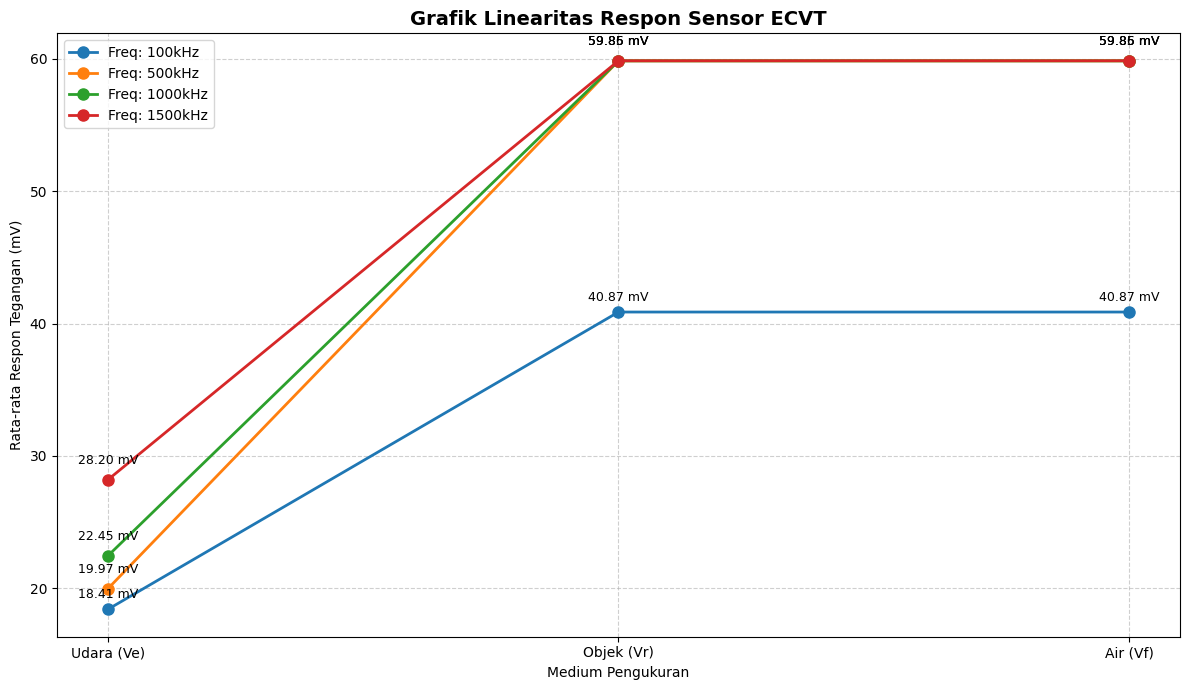

In [8]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_linearity_analysis(ve_path, vf_path, vr_path):
    try:
        # 1. Loading Data (3 Kondisi)
        mat_ve = scipy.io.loadmat(ve_path)
        mat_vf = scipy.io.loadmat(vf_path)
        mat_vr = scipy.io.loadmat(vr_path)

        freqs = mat_ve['LS_FREQS'].flatten()
        
        # Mengambil rata-rata global tegangan untuk setiap frekuensi
        # axis=0 untuk rata-rata antar elektroda, axis=1 untuk rata-rata antar frame
        ve_avg = np.mean(mat_ve['Ve_kalibrasi'], axis=(0, 1))
        vf_avg = np.mean(mat_vf['Vf_kalibrasi'], axis=(0, 1))
        vr_avg = np.mean(mat_vr['Vf_kalibrasi'], axis=(0, 1)) # Vr biasanya di simpan di Vf_kalibrasi file objek

        # 2. Plotting
        plt.figure(figsize=(12, 7))
        
        materials = ['Udara (Ve)', 'Objek (Vr)', 'Air (Vf)']
        material_indices = [1, 2, 80] # Representasi permitivitas relatif (Air ~80)

        for i, freq in enumerate(freqs):
            label_freq = f"{freq:.0f}kHz"
            voltages = [ve_avg[i], vr_avg[i], vf_avg[i]]
            
            # Plot garis linearitas
            plt.plot(materials, voltages, marker='o', markersize=8, linewidth=2, label=f'Freq: {label_freq}')
            
            # Tambahkan anotasi nilai
            for j, v in enumerate(voltages):
                plt.text(j, v + (max(voltages)*0.02), f'{v:.2f} mV', ha='center', fontsize=9)

        plt.title('Grafik Linearitas Respon Sensor ECVT', fontweight='bold', fontsize=14)
        plt.ylabel('Rata-rata Respon Tegangan (mV)')
        plt.xlabel('Medium Pengukuran')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}. Pastikan file Vr (objek) sudah benar.")

# --- KONFIGURASI PATH ---
# Ganti path di bawah sesuai lokasi file objek (Vr) Anda
ve_file = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat'
vf_file = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat' 
vr_file = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat' 


# Jalankan
plot_linearity_analysis(ve_file, vf_file, vr_file)

analisis gap & stabilitas (noise)

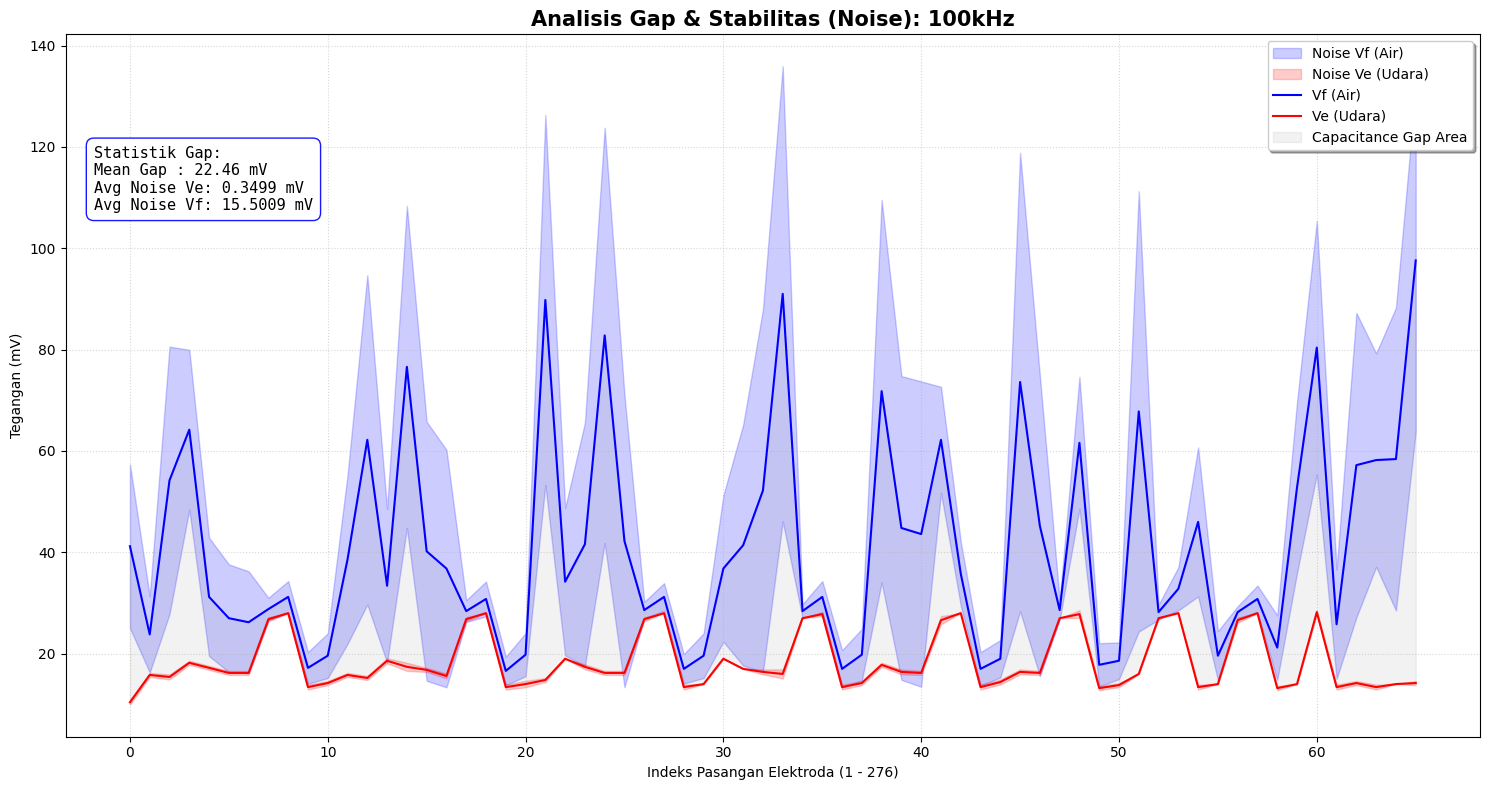

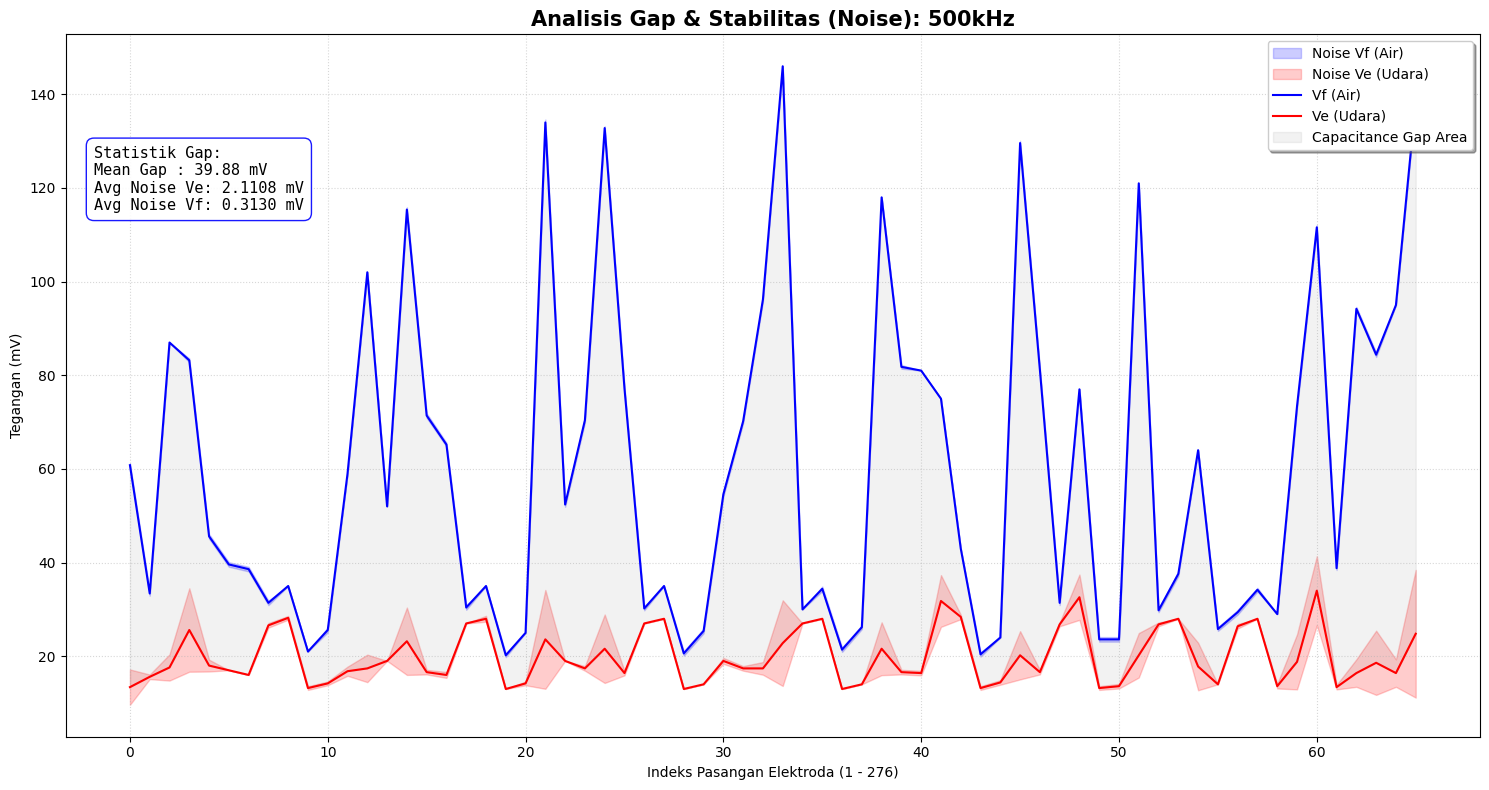

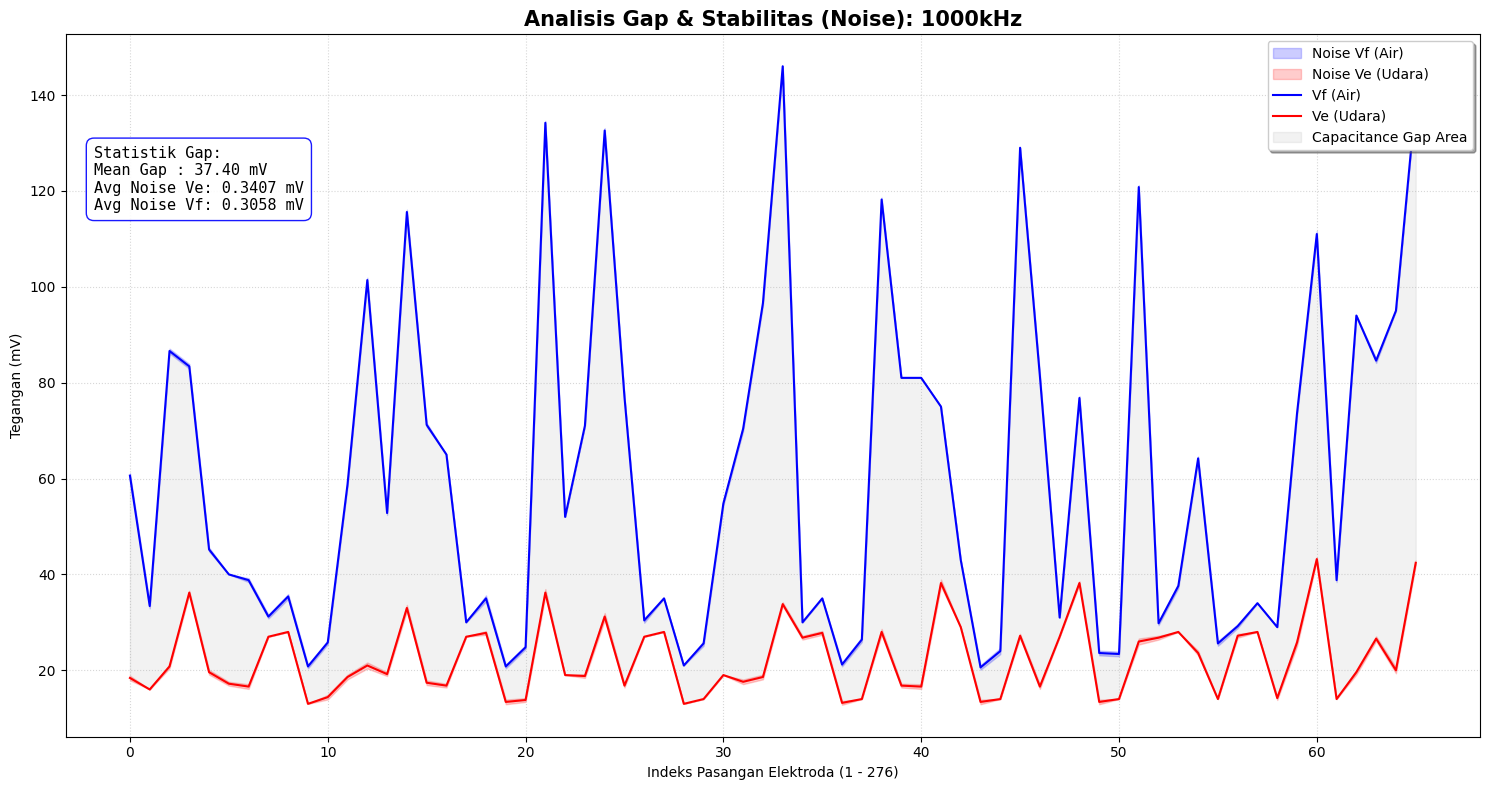

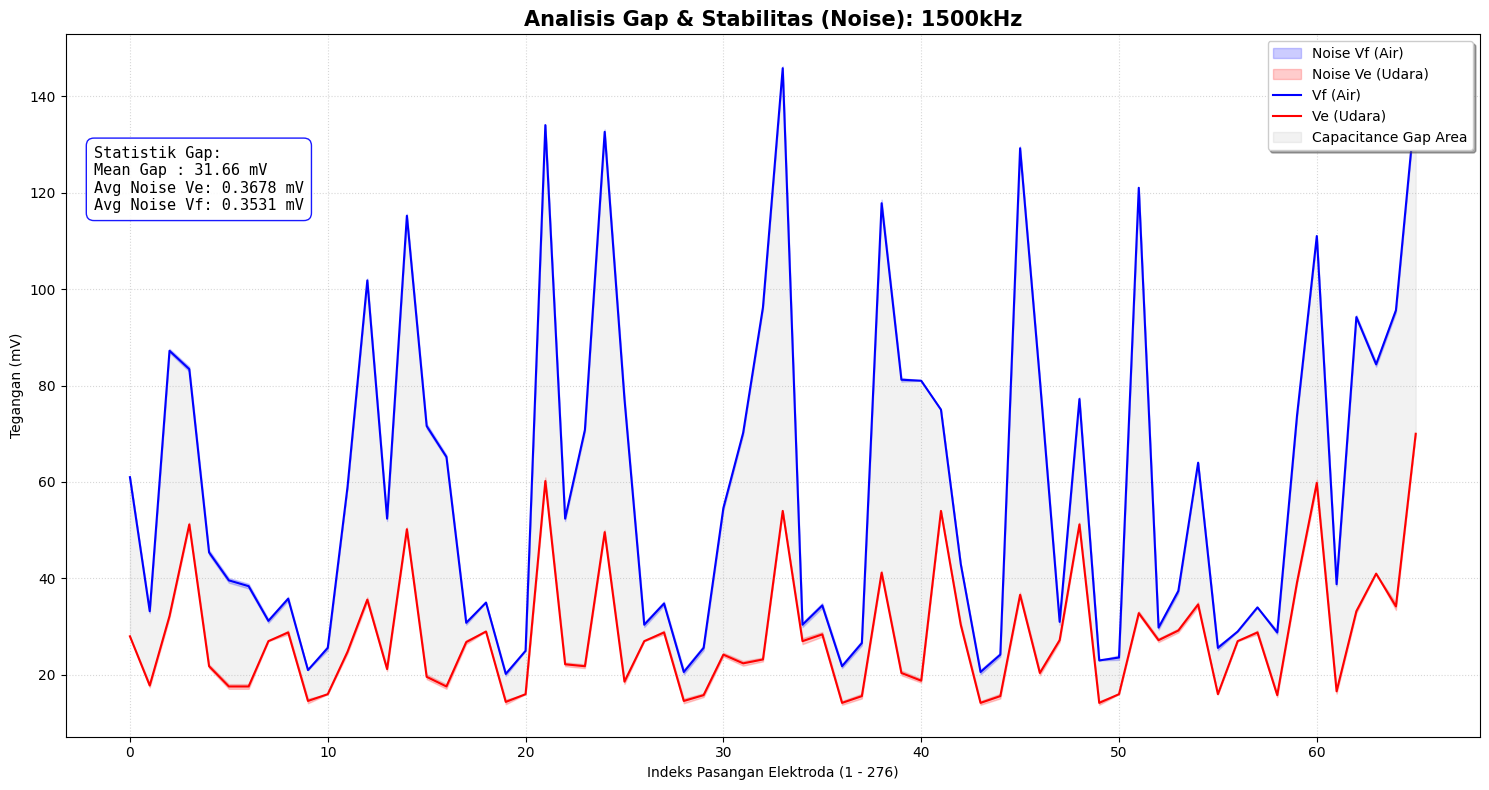

In [9]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gap_with_noise_analysis(file_path):
    try:
        # 1. Loading Data
        mat_data = scipy.io.loadmat(file_path)
        freqs_raw = mat_data['LS_FREQS'].flatten()
        
        # Mengambil data mentah untuk menghitung noise (std dev)
        ve_raw = mat_data['Ve_kalibrasi'] # Shape: [276, frames, freqs]
        vf_raw = mat_data['Vf_kalibrasi']
        
        indices = np.arange(ve_raw.shape[0])

        for i, freq_val in enumerate(freqs_raw):
            current_freq_label = f"{freq_val:.0f}kHz"
            
            # Hitung Mean (untuk garis utama)
            ve_mean = np.mean(ve_raw[:, :, i], axis=1)
            vf_mean = np.mean(vf_raw[:, :, i], axis=1)
            
            # Hitung Std Dev (Inilah Noisenya)
            ve_std = np.std(ve_raw[:, :, i], axis=1)
            vf_std = np.std(vf_raw[:, :, i], axis=1)
            
            gap = vf_mean - ve_mean
            
            # --- Statistik Gap ---
            mean_gap = np.mean(gap)
            std_gap = np.std(gap)

            # 2. Plotting
            plt.figure(figsize=(15, 8))
            
            # Plot Area Noise (Std Dev) - Inilah visualisasi noisenya
            plt.fill_between(indices, vf_mean - vf_std, vf_mean + vf_std, color='blue', alpha=0.2, label='Noise Vf (Air)')
            plt.fill_between(indices, ve_mean - ve_std, ve_mean + ve_std, color='red', alpha=0.2, label='Noise Ve (Udara)')
            
            # Garis Utama Vf dan Ve
            plt.plot(indices, vf_mean, label='Vf (Air)', color='blue', linewidth=1.5)
            plt.plot(indices, ve_mean, label='Ve (Udara)', color='red', linewidth=1.5)
            
            # Arsir Area Gap (wilayah antara Ve dan Vf)
            plt.fill_between(indices, ve_mean, vf_mean, color='gray', alpha=0.1, label='Capacitance Gap Area')

            # 3. Styling
            plt.title(f'Analisis Gap & Stabilitas (Noise): {current_freq_label}', fontweight='bold', fontsize=15)
            plt.xlabel('Indeks Pasangan Elektroda (1 - 276)')
            plt.ylabel('Tegangan (mV)')
            
            # Info Box
            stats_box = (
                f"Statistik Gap:\n"
                f"Mean Gap : {mean_gap:.2f} mV\n"
                f"Avg Noise Ve: {np.mean(ve_std):.4f} mV\n"
                f"Avg Noise Vf: {np.mean(vf_std):.4f} mV"
            )
            plt.annotate(stats_box, xy=(0.02, 0.75), xycoords='axes fraction', 
                         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="blue", alpha=0.9),
                         fontsize=11, family='monospace')

            plt.legend(loc='upper right', frameon=True, shadow=True)
            plt.grid(True, which='both', linestyle=':', alpha=0.5)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Jalankan fungsi
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat'
plot_gap_with_noise_analysis(file_path)

standar deviasi, LOD, dan LOQ

In [12]:
import scipy.io
import numpy as np
import pandas as pd
import os

# 1. KONFIGURASI DATA
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_2.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_3.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_4.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_5.dat'
]

THRESHOLD_AWAL = 4.10 
TARGET_FREQS = ['100kHz', '500kHz', '1000kHz', '1500kHz']

# 2. PROSES LOADING & EKSTRAKSI NOISE RIIL
all_stats = []

print("--- MEMPROSES ANALISIS METROLOGI MULTI-TRIAL ---")

for f_path in FILE_PATHS:
    try:
        mat = scipy.io.loadmat(f_path)
        freqs_raw = mat['LS_FREQS'].flatten()
        ve_raw = mat['Ve_kalibrasi'] 
        vf_mean = np.mean(mat['Vf_kalibrasi'], axis=1)
        ve_mean = np.mean(ve_raw, axis=1)
        
        trial_data = {}
        for idx, f in enumerate(freqs_raw):
            f_label = f"{f}kHz"
            if f_label not in TARGET_FREQS: continue
            
            # Sigma Temporal (Noise per file)
            std_per_ch = np.std(ve_raw[:, :, idx], axis=1)
            sigma_aktual = np.mean(std_per_ch) 
            
            gap = vf_mean[:, idx] - ve_mean[:, idx]
            is_alive = gap > THRESHOLD_AWAL
            sig_mean = np.mean(gap[is_alive]) if np.any(is_alive) else 0
            
            trial_data[f_label] = {
                'sigma': sigma_aktual,
                'gap_mean': sig_mean,
                'dz': np.sum(~is_alive)
            }
        all_stats.append(trial_data)
        print(f"File {os.path.basename(f_path)} sukses.")
    except Exception as e:
        print(f"Error pada {f_path}: {e}")

# 3. AGREGASI & PERHITUNGAN METROLOGI LANJUTAN
final_metrologi = []

for f_label in TARGET_FREQS:
    # Ekstraksi list untuk hitung stabilitas antar trial (RSD)
    sigma_list = [t[f_label]['sigma'] for t in all_stats if f_label in t]
    gap_list = [t[f_label]['gap_mean'] for t in all_stats if f_label in t]
    dz_list = [t[f_label]['dz'] for t in all_stats if f_label in t]
    
    avg_sigma = np.mean(sigma_list)
    avg_gap = np.mean(gap_list)
    avg_dz = np.mean(dz_list)
    
    # Metrologi IUPAC & 11-Sigma
    lod = 3 * avg_sigma
    loq = 10 * avg_sigma
    sigma_11 = 11 * avg_sigma
    sigma_15 = 15 * avg_sigma
    snr_db = 20 * np.log10(avg_gap / avg_sigma) if avg_gap > 0 else 0
    noise_contr = (avg_sigma / THRESHOLD_AWAL) * 100
    
    # Penentuan Status berdasarkan Noise Contribution
    if noise_contr <= 7:
        status = "HIGH FIDELITY"
    elif noise_contr <= 10:
        status = "VALID"
    else:
        status = "UNSTABLE"

    final_metrologi.append({
        'Freq': f_label,
        'Sigma': round(avg_sigma, 4),
        'LOD(3σ)': round(lod, 2),
        'LOQ(10σ)': round(loq, 2),
        '11-Sigma': round(sigma_11, 2),
        '15-Sigma': round(sigma_15, 2),
        'SNR(dB)': round(snr_db, 2),
        'Noise_Contr(%)': round(noise_contr, 2),
        'DeadZones': int(round(avg_dz)),
        'Status': status
    })

df_final = pd.DataFrame(final_metrologi)

# 4. TAMPILKAN HASIL
print("\n" + "="*110)
print("TABEL ANALISIS METROLOGI & STABILITAS SENSOR (GABUNGAN 5 TRIAL)")
print("="*110)
print(df_final.to_string(index=False))
print("-" * 110)



--- MEMPROSES ANALISIS METROLOGI MULTI-TRIAL ---
File breast_udara_12ch_1.dat sukses.
File breast_udara_12ch_2.dat sukses.
File breast_udara_12ch_3.dat sukses.
File breast_udara_12ch_4.dat sukses.
File breast_udara_12ch_5.dat sukses.

TABEL ANALISIS METROLOGI & STABILITAS SENSOR (GABUNGAN 5 TRIAL)
   Freq  Sigma  LOD(3σ)  LOQ(10σ)  11-Sigma  15-Sigma  SNR(dB)  Noise_Contr(%)  DeadZones   Status
 100kHz 0.3499     1.05      3.50      3.85      5.25    38.47            8.53         17    VALID
 500kHz 2.1108     6.33     21.11     23.22     31.66    26.16           51.48          5 UNSTABLE
1000kHz 0.3407     1.02      3.41      3.75      5.11    41.57            8.31          6    VALID
1500kHz 0.3678     1.10      3.68      4.05      5.52    39.45            8.97          6    VALID
--------------------------------------------------------------------------------------------------------------


Persebaran titik channel aktif

Frekuensi 1: Valid=53, Tereliminasi=13
Frekuensi 2: Valid=61, Tereliminasi=5
Frekuensi 3: Valid=61, Tereliminasi=5
Frekuensi 4: Valid=62, Tereliminasi=4


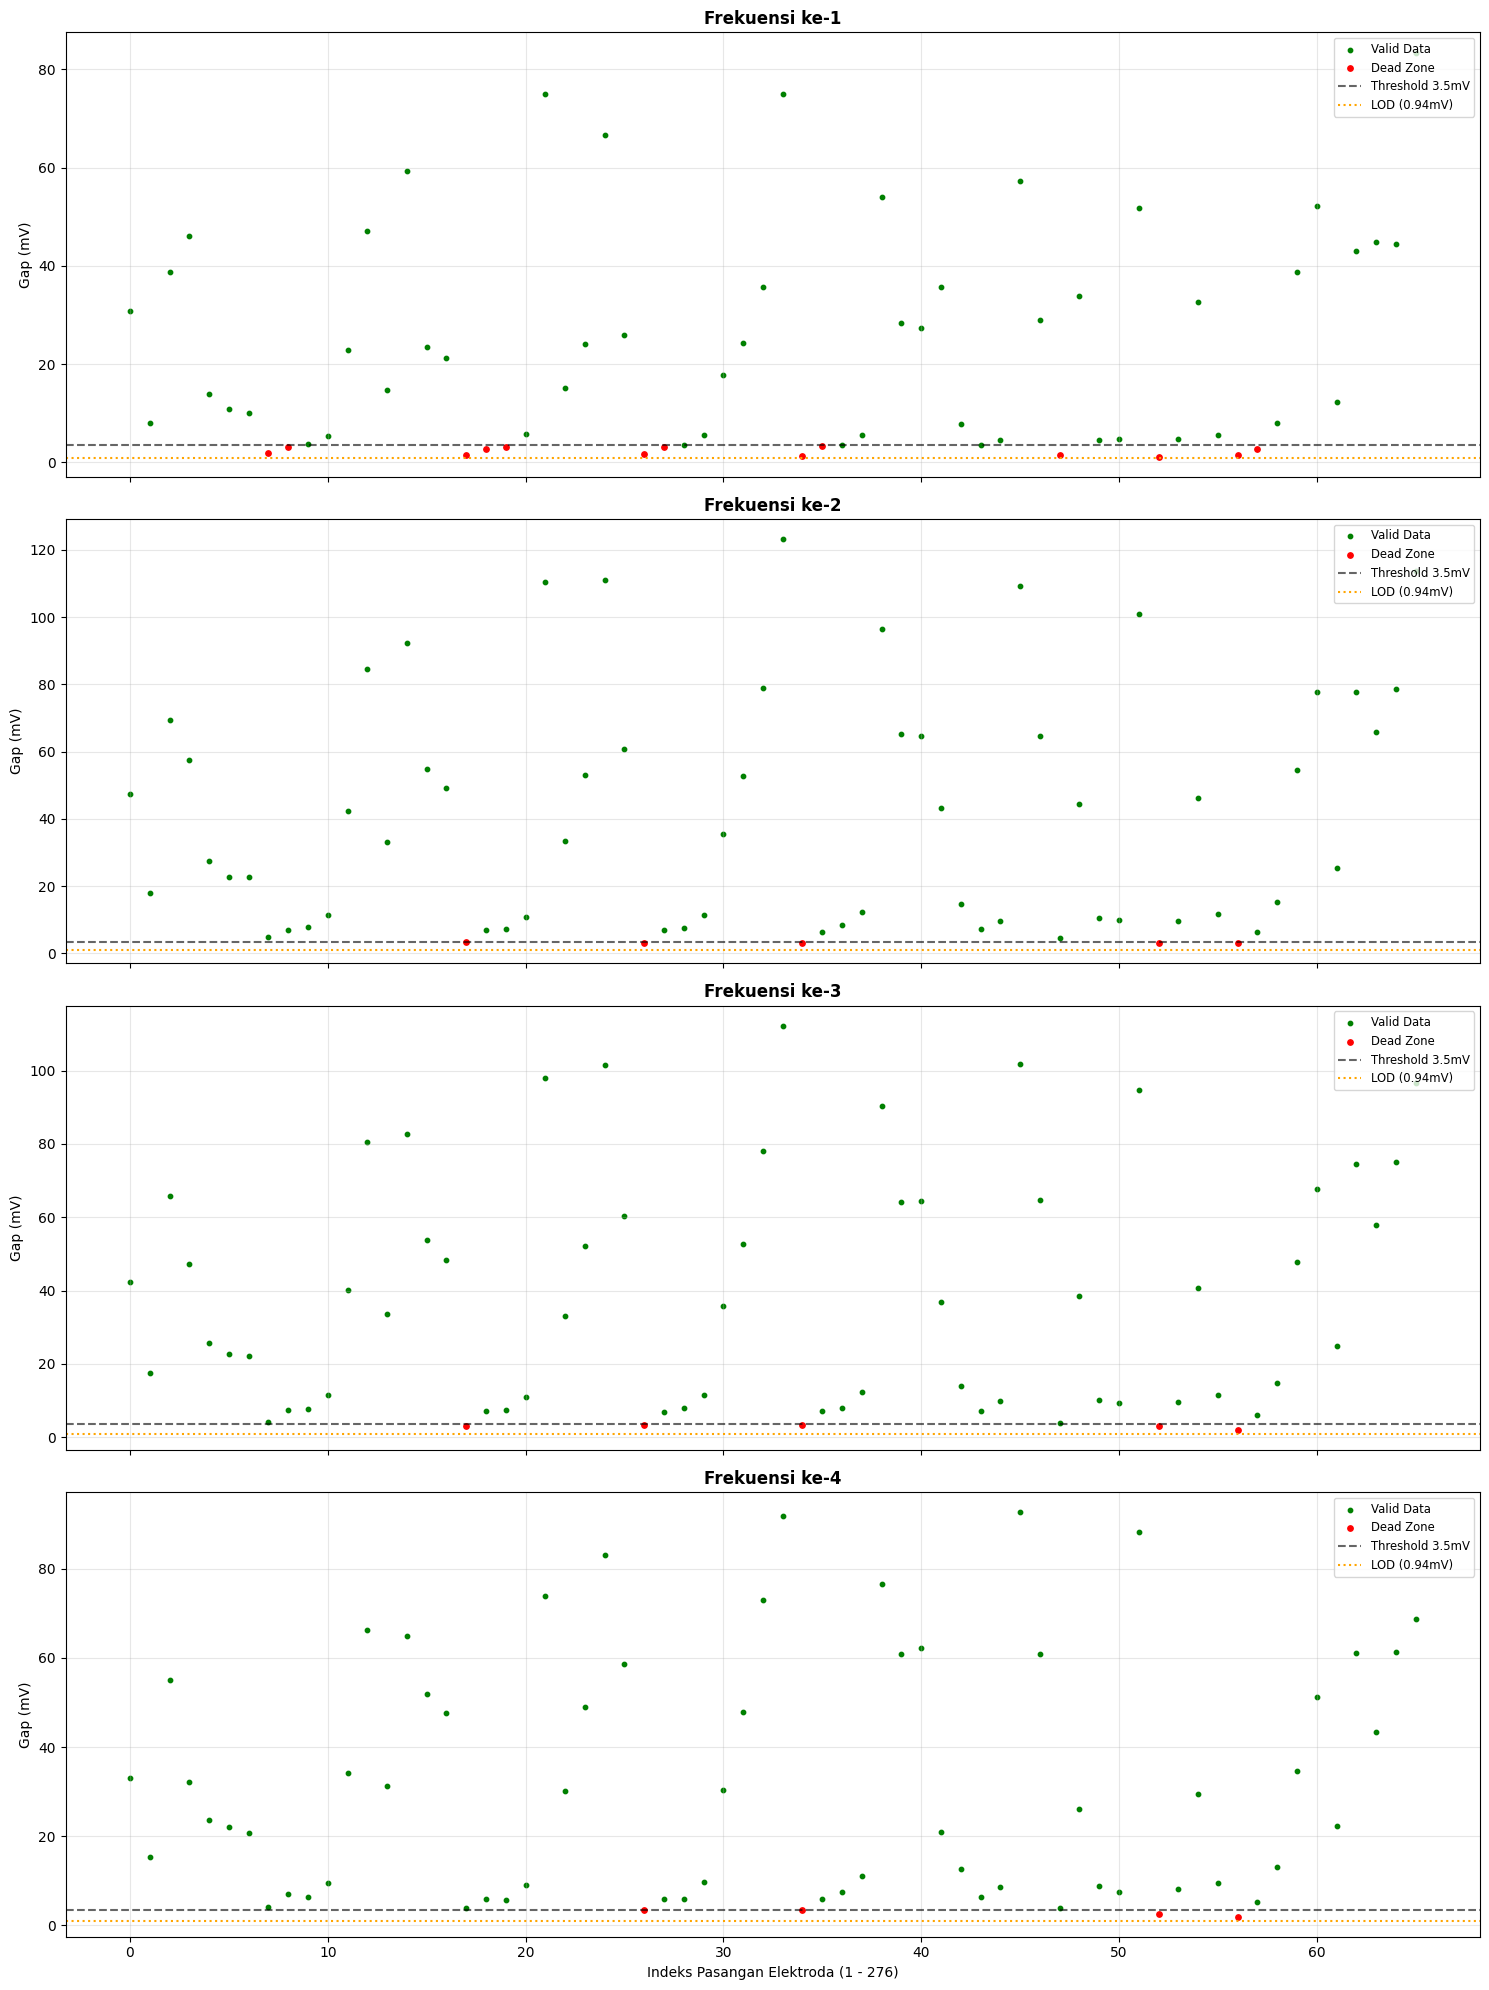

In [13]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def analyze_all_frequencies(file_path, threshold=4.10):
    try:
        mat_data = scipy.io.loadmat(file_path)
        # Menghitung rata-rata tegangan
        ve_mean = np.mean(mat_data['Ve_kalibrasi'], axis=1) # Hasil: [276, jumlah_frekuensi]
        vf_mean = np.mean(mat_data['Vf_kalibrasi'], axis=1)
        
        num_freq = ve_mean.shape[1] # Mendeteksi jumlah frekuensi otomatis
        indices = np.arange(ve_mean.shape[0]) # 0 sampai 275

        # Membuat subplots agar semua frekuensi tampil dalam satu window
        fig, axes = plt.subplots(num_freq, 1, figsize=(15, 5 * num_freq), sharex=True)
        
        # Jika hanya ada 1 frekuensi, wrap axes ke list agar tidak error saat looping
        if num_freq == 1:
            axes = [axes]

        for f in range(num_freq):
            gap = vf_mean[:, f] - ve_mean[:, f]
            
            dead_mask = gap < threshold
            alive_mask = ~dead_mask
            
            ax = axes[f]
            # Plot data
            ax.scatter(indices[alive_mask], gap[alive_mask], color='green', s=10, label='Valid Data')
            ax.scatter(indices[dead_mask], gap[dead_mask], color='red', s=15, label='Dead Zone')
            
            # Garis Bantu
            ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6, label=f'Threshold {threshold}mV')
            ax.axhline(y=0.94, color='orange', linestyle=':', label='LOD (0.94mV)')
            
            ax.set_title(f'Frekuensi ke-{f+1}', fontweight='bold')
            ax.set_ylabel('Gap (mV)')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize='small')
            
            print(f"Frekuensi {f+1}: Valid={np.sum(alive_mask)}, Tereliminasi={np.sum(dead_mask)}")

        plt.xlabel('Indeks Pasangan Elektroda (1 - 276)')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat'
analyze_all_frequencies(file_path, threshold=3.5)

analisis data tunggal

--- LOADING DATA: breast_udara_12ch_3.dat ---

--- ANALISIS GAP PER FREKUENSI ---
100kHz -> Gap Min: 1.20, Max: 83.40
500kHz -> Gap Min: 3.00, Max: 123.20
1000kHz -> Gap Min: 2.00, Max: 112.20
1500kHz -> Gap Min: 2.00, Max: 92.60

Success: Loaded data.
nilai gap min: 1.20, max: 123.20

--- DETAIL PERHITUNGAN PER FREKUENSI ---
Frekuensi: 100kHz
 - Jumlah elektroda dead zone: 17
 - Signal Mean: 0.005605
 - Noise Mean: 0.000000 (Eff: 0.000010)
 - SNR: 54.97 dB
-----------------------------------
Frekuensi: 500kHz
 - Jumlah elektroda dead zone: 5
 - Signal Mean: 0.034474
 - Noise Mean: 0.000000 (Eff: 0.000010)
 - SNR: 70.75 dB
-----------------------------------
Frekuensi: 1000kHz
 - Jumlah elektroda dead zone: 6
 - Signal Mean: 0.126868
 - Noise Mean: 0.000000 (Eff: 0.000010)
 - SNR: 82.07 dB
-----------------------------------
Frekuensi: 1500kHz
 - Jumlah elektroda dead zone: 6
 - Signal Mean: 0.875915
 - Noise Mean: 0.000000 (Eff: 0.000010)
 - SNR: 98.85 dB
-----------------------------

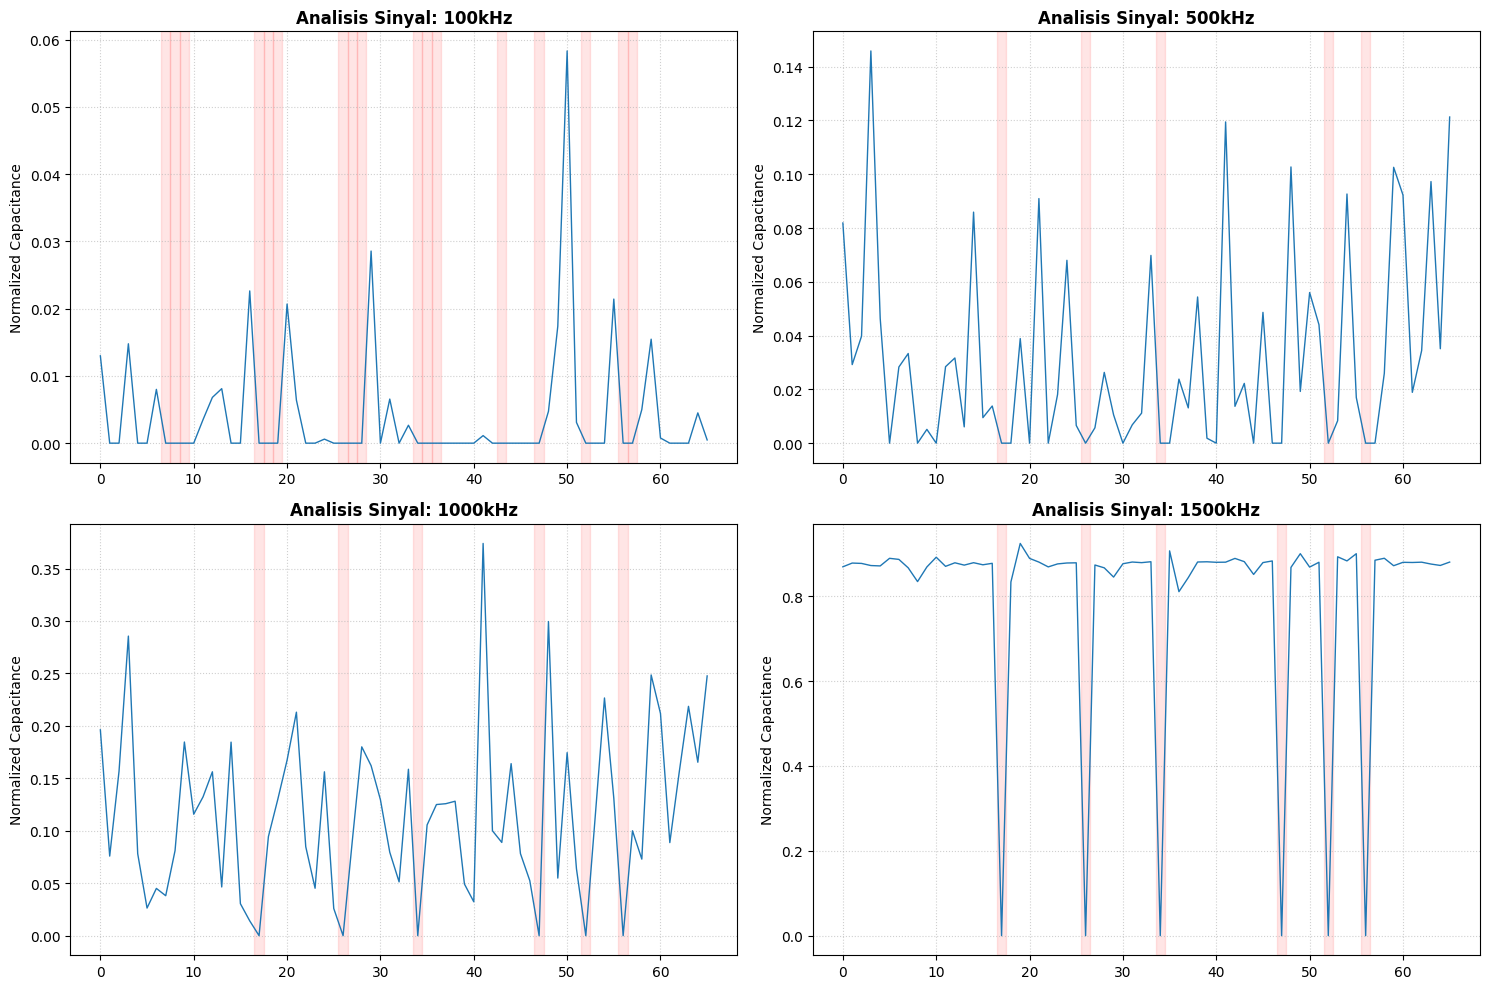

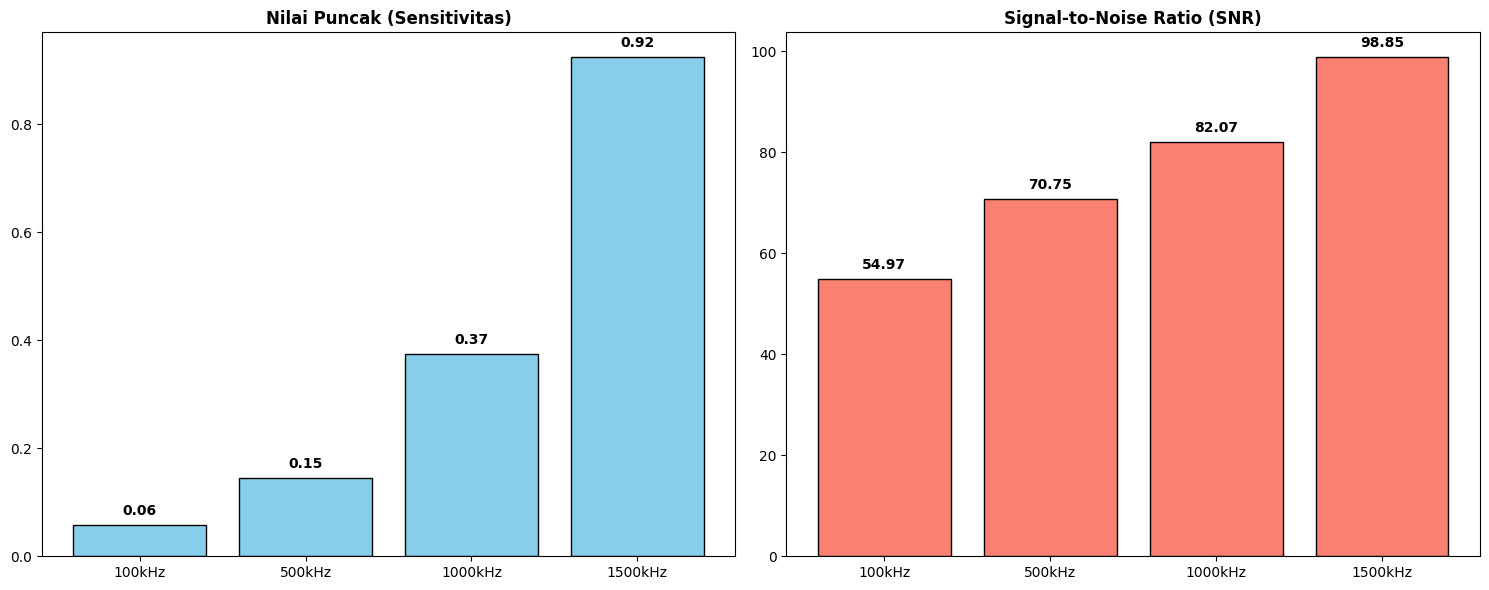


=== FINAL ANALYSIS SUMMARY ===
Frequency  Peak_Mean  standar deviasi  SNR_dB  Peak_Electrode  Dead_Zones
   100kHz     0.0583          0.00001   54.97              50          17
   500kHz     0.1458          0.00001   70.75               3           5
  1000kHz     0.3739          0.00001   82.07              41           6
  1500kHz     0.9241          0.00001   98.85              19           6


In [24]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. KONFIGURASI & SETUP
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_3.dat'
OUTPUT_FOLDER = r'C:\Users\ASUS\Desktop\Analisis_Single_Trial'
THRESHOLD_DEADZONE = 4.1 
TARGET_FREQS = ['100kHz', '500kHz', '1000kHz', '1500kHz']
COLOR = '#1f77b4'

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# 2. PROSES LOADING & NORMALISASI
print(f"--- LOADING DATA: {os.path.basename(FILE_PATH)} ---")

try:
    mat_data = scipy.io.loadmat(FILE_PATH)
    freqs_raw = mat_data['LS_FREQS'].flatten()
    m_val = mat_data['m'][0][0]
    
    ve_mean = np.mean(mat_data['Ve_kalibrasi'], axis=1)
    vf_mean = np.mean(mat_data['Vf_kalibrasi'], axis=1)
    vr_mean = np.mean(mat_data['Vr_all'], axis=1)
    
    trial_norm = {}
    trial_gap = {}
    all_gaps_collector = []

    # --- OUTPUT ANALISIS GAP PER FREKUENSI ---
    print("\n--- ANALISIS GAP PER FREKUENSI ---")
    
    for idx, f in enumerate(freqs_raw):
        f_label = f"{f}kHz"
        
        # PERHITUNGAN GAP SPESIFIK FREKUENSI
        gap_freq = vf_mean[:, idx] - ve_mean[:, idx]
        all_gaps_collector.extend(gap_freq)
        
        # Cetak Min/Max Gap per frekuensi
        print(f"{f_label} -> Gap Min: {np.min(gap_freq):.2f}, Max: {np.max(gap_freq):.2f}")
        
        # Normalisasi menggunakan gap frekuensi ini
        mask = gap_freq > THRESHOLD_DEADZONE
        c_norm = np.zeros(m_val)
        c_norm[mask] = (vr_mean[mask, idx] - ve_mean[mask, idx]) / gap_freq[mask]
        c_norm = np.clip(c_norm, 0, 1)
        
        trial_norm[f_label] = c_norm
        trial_gap[f_label] = gap_freq

    print("\nSuccess: Loaded data.")
    print(f"nilai gap min: {np.min(all_gaps_collector):.2f}, max: {np.max(all_gaps_collector):.2f}")

except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# 3. VISUALISASI LINE PLOT (Sinyal per Elektroda)
plt.figure(figsize=(15, 10))
for i, f_label in enumerate(TARGET_FREQS):
    plt.subplot(2, 2, i+1)
    plt.plot(trial_norm[f_label], color=COLOR, linewidth=1)
    
    # Arsir Dead Zone menggunakan gap spesifik frekuensi tersebut
    dead_indices = np.where(trial_gap[f_label] < THRESHOLD_DEADZONE)[0]
    for d_idx in dead_indices:
        plt.axvspan(d_idx-0.5, d_idx+0.5, color='red', alpha=0.1)
        
    plt.title(f'Analisis Sinyal: {f_label}', fontweight='bold')
    plt.ylabel('Normalized Capacitance')
    plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'Line_Plot_Sinyal.png'))

# 4. ANALISIS STATISTIK & SNR
stats_list = []
print("\n--- DETAIL PERHITUNGAN PER FREKUENSI ---")

for f_label in TARGET_FREQS:
    c_norm = trial_norm[f_label]
    gap_freq = trial_gap[f_label]
    
    peak_val = np.max(c_norm)
    peak_idx = np.argmax(c_norm)
    
    is_dead = gap_freq < THRESHOLD_DEADZONE
    num_dead = np.sum(is_dead)
    
    signal_area = c_norm[~is_dead]
    noise_area = c_norm[is_dead]
    
    signal_mean = signal_area.mean() if signal_area.size > 0 else 0
    noise_mean = noise_area.mean() if noise_area.size > 0 else 0
    
    # Logika Noise Floor Injection
    noise_floor = 1e-5
    effective_noise = noise_mean if noise_mean > noise_floor else noise_floor

    if signal_mean > 0:
        snr_db = 20 * np.log10(signal_mean / effective_noise)
    else:
        snr_db = 0.0
        
    print(f"Frekuensi: {f_label}")
    print(f" - Jumlah elektroda dead zone: {num_dead}")
    print(f" - Signal Mean: {signal_mean:.6f}")
    print(f" - Noise Mean: {noise_mean:.6f} (Eff: {effective_noise:.6f})")
    print(f" - SNR: {snr_db:.2f} dB")
    print("-" * 35)

    stats_list.append({
        'Frequency': f_label,
        'Peak_Mean': round(peak_val, 4),
        'standar deviasi': effective_noise,
        'SNR_dB': round(snr_db, 2),
        'Peak_Electrode': peak_idx,
        'Dead_Zones': num_dead
    })

df_stats = pd.DataFrame(stats_list)

# 5. VISUALISASI BAR CHART (Summary)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(df_stats['Frequency'], df_stats['Peak_Mean'], color='skyblue', edgecolor='black')
ax1.set_title('Nilai Puncak (Sensitivitas)', fontweight='bold')
ax2.bar(df_stats['Frequency'], df_stats['SNR_dB'], color='salmon', edgecolor='black')
ax2.set_title('Signal-to-Noise Ratio (SNR)', fontweight='bold')

for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_FOLDER, 'Bar_Chart_Summary.png'))
plt.show()

# 6. FINAL SUMMARY
print("\n=== FINAL ANALYSIS SUMMARY ===")
summary_display = df_stats[['Frequency', 'Peak_Mean', 'standar deviasi', 'SNR_dB', 'Peak_Electrode', 'Dead_Zones']]
print(summary_display.to_string(index=False))

analisis data tunggal persebaran fluktuasi dan gap


HASIL ANALISIS SNR BERDASARKAN FLUKTUASI TEMPORAL
Frequency  Signal_Mean(mV)  Noise_Temporal(mV)  SNR_dB
   100kHz            29.35              0.4714   35.88
   500kHz            42.90              1.6256   28.43
  1000kHz            40.83              2.1620   25.52
  1500kHz            34.51             11.2160    9.76


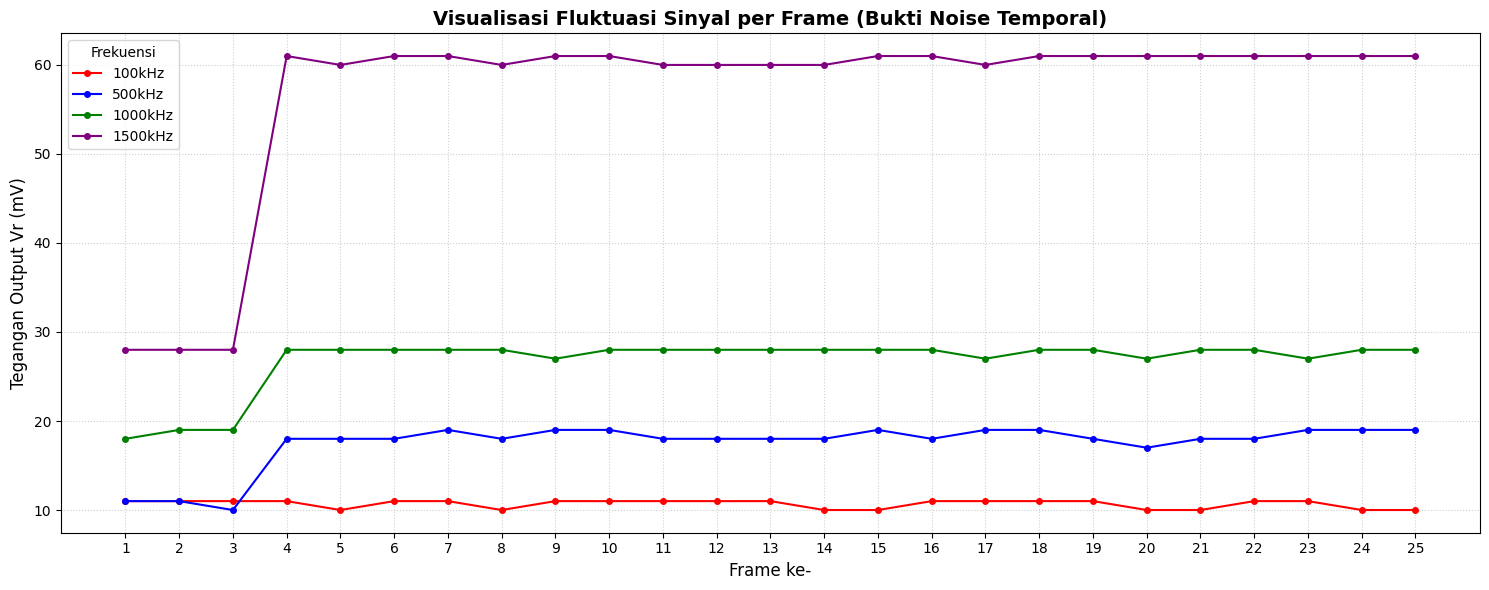

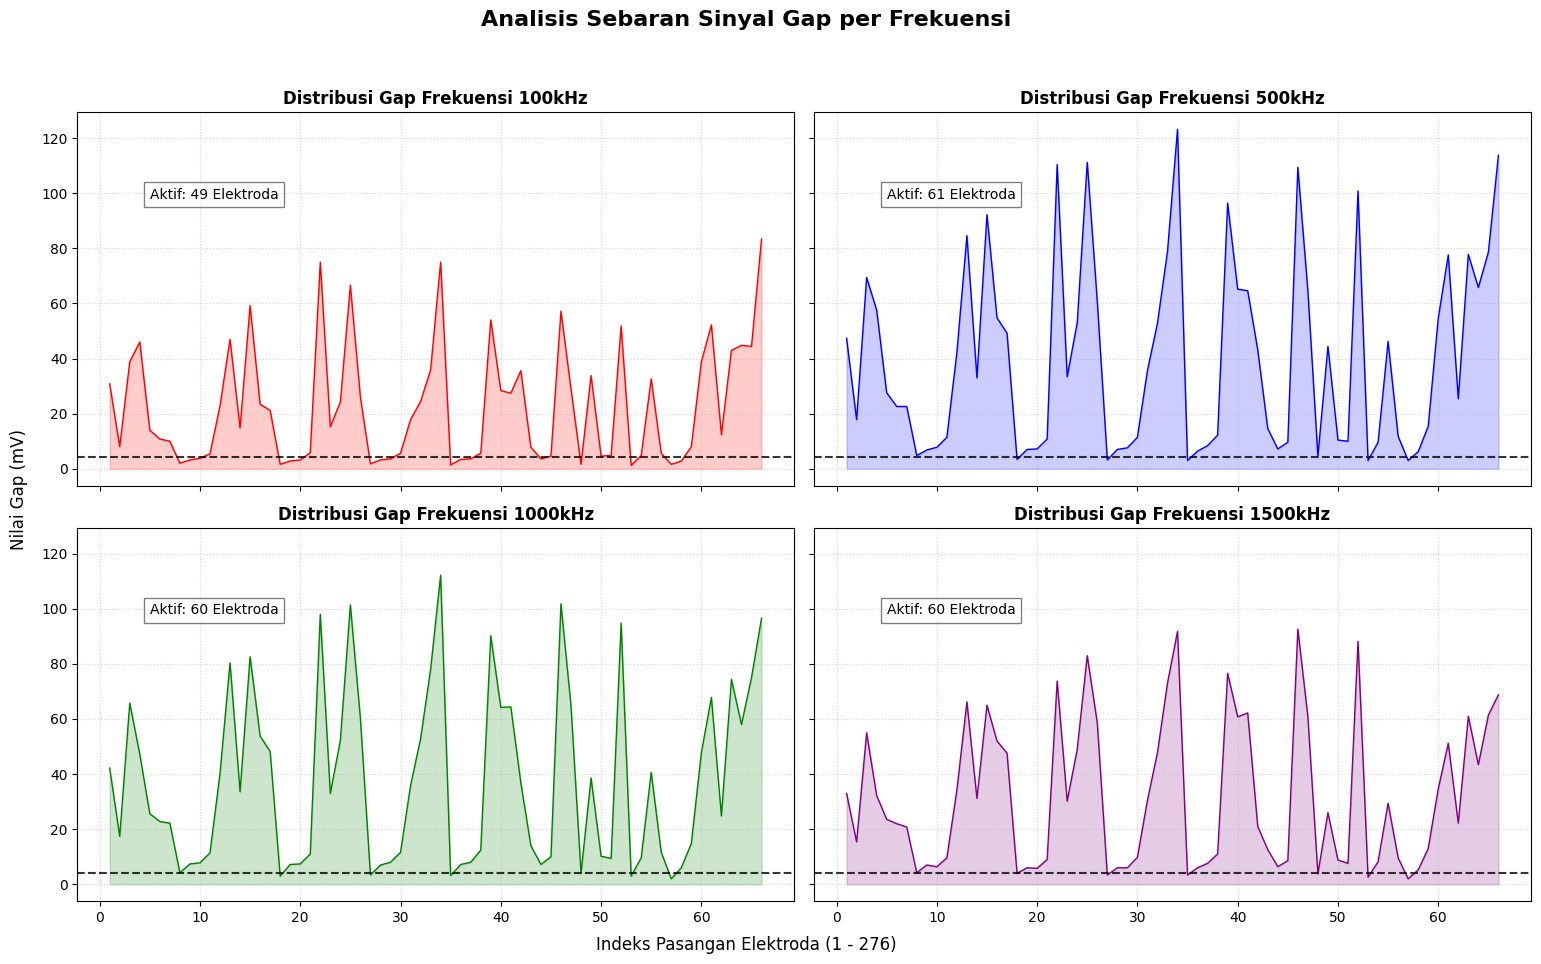

In [19]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. KONFIGURASI FILE
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat'
THRESHOLD_DEADZONE = 4.1 
TARGET_FREQS = ['100kHz', '500kHz', '1000kHz', '1500kHz']

try:
    # 2. LOAD DATA
    mat_data = scipy.io.loadmat(FILE_PATH)
    freqs_raw = mat_data['LS_FREQS'].flatten()
    vr_all_frames = mat_data['Vr_all'] 
    ve_mean = np.mean(mat_data['Ve_kalibrasi'], axis=1)
    vf_mean = np.mean(mat_data['Vf_kalibrasi'], axis=1)

    stats_list = []
    
    # Setup Figure untuk Grafik
    plt.figure(figsize=(15, 6))
    
    # Warna untuk setiap frekuensi agar konsisten
    colors = {'100kHz': 'red', '500kHz': 'blue', '1000kHz': 'green', '1500kHz': 'purple'}

    for idx, f in enumerate(freqs_raw):
        f_label = f"{f}kHz"
        if f_label not in TARGET_FREQS: continue
        
        # --- A. ANALISIS STATISTIK ---
        gap_freq = vf_mean[:, idx] - ve_mean[:, idx]
        mask_alive = gap_freq > THRESHOLD_DEADZONE
        
        # Signal Mean
        signal_mean = np.mean(gap_freq[mask_alive]) if np.any(mask_alive) else 0
        
        # Temporal Noise (Fluktuasi 25 Frame)
        data_frames = vr_all_frames[:, :, idx] 
        std_per_electrode = np.std(data_frames, axis=1) 
        temporal_noise = np.mean(std_per_electrode[mask_alive]) if np.any(mask_alive) else 1e-5

        # SNR Calculation
        snr_db = 20 * np.log10(signal_mean / temporal_noise) if signal_mean > 0 else 0

        stats_list.append({
            'Frequency': f_label,
            'Signal_Mean(mV)': round(signal_mean, 2),
            'Noise_Temporal(mV)': round(temporal_noise, 4),
            'SNR_dB': round(snr_db, 2)
        })

        # --- B. VISUALISASI FLUKTUASI (FRAME-BY-FRAME) ---
        # Kita ambil satu elektroda sampel yang aktif (misal indeks pertama yang alive)
        sample_idx = np.where(mask_alive)[0][0] 
        sample_data = data_frames[sample_idx, :]
        
        plt.plot(range(1, 26), sample_data, label=f_label, 
                 marker='o', color=colors[f_label], linewidth=1.5, markersize=4)

    # 3. TAMPILKAN TABEL HASIL
    df_result = pd.DataFrame(stats_list)
    print("\n" + "="*50)
    print("HASIL ANALISIS SNR BERDASARKAN FLUKTUASI TEMPORAL")
    print("="*50)
    print(df_result.to_string(index=False))
    print("="*50)

    # 4. TAMPILKAN GRAFIK
    plt.title('Visualisasi Fluktuasi Sinyal per Frame (Bukti Noise Temporal)', fontsize=14, fontweight='bold')
    plt.xlabel('Frame ke-', fontsize=12)
    plt.ylabel('Tegangan Output Vr (mV)', fontsize=12)
    plt.xticks(range(1, 26))
    plt.legend(title="Frekuensi")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

# Setup Figure dengan 4 Subplot (2 baris x 2 kolom)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten() # Mengubah matriks 2x2 jadi list agar mudah di-loop

for i, f_label in enumerate(TARGET_FREQS):
    # Cari index frekuensi yang sesuai di freqs_raw
    f_val = int(f_label.replace('kHz', ''))
    idx = np.where(freqs_raw == f_val)[0][0]
    
    gap_freq = vf_mean[:, idx] - ve_mean[:, idx]
    electrodes = np.arange(1, len(gap_freq) + 1)
    
    # Plot di masing-masing subplot
    axes[i].plot(electrodes, gap_freq, color=colors[f_label], linewidth=1)
    axes[i].fill_between(electrodes, gap_freq, color=colors[f_label], alpha=0.2) # Memberi arsiran agar lebih jelas
    
    # Garis Threshold
    axes[i].axhline(y=THRESHOLD_DEADZONE, color='black', linestyle='--', alpha=0.8)
    
    # Keterangan tiap kotak
    axes[i].set_title(f'Distribusi Gap Frekuensi {f_label}', fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle=':', alpha=0.5)
    
    # Menghitung jumlah elektroda aktif untuk ditampilkan di teks
    active_count = np.sum(gap_freq > THRESHOLD_DEADZONE)
    axes[i].text(5, 98, f'Aktif: {active_count} Elektroda', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# Label Umum
fig.text(0.5, 0.04, 'Indeks Pasangan Elektroda (1 - 276)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Nilai Gap (mV)', va='center', rotation='vertical', fontsize=12)

plt.suptitle('Analisis Sebaran Sinyal Gap per Frekuensi', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


analisis data gabungan

--- MEMULAI PROSES GABUNGAN 5 TRIAL ---
Trial 1 sukses diproses.
Trial 2 sukses diproses.
Trial 3 sukses diproses.
Trial 4 sukses diproses.
Trial 5 sukses diproses.

=== FINAL AGGREGATED SUMMARY (5 TRIALS) ===
Frequency  Peak_Mean  Peak_Std  RSD_%  SNR_Avg  Dead_Zones_Avg
   100kHz     0.0550    0.0085  15.45    39.40              17
   500kHz     0.1472    0.0023   1.55    42.69               5
  1000kHz     0.3711    0.0020   0.54    42.26               6
  1500kHz     0.9170    0.0154   1.68    40.80               6

Kesimpulan Frekuensi Optimal: 500kHz
Alasan: Memiliki rata-rata Dead Zone terendah (5) dan SNR stabil (42.69 dB).


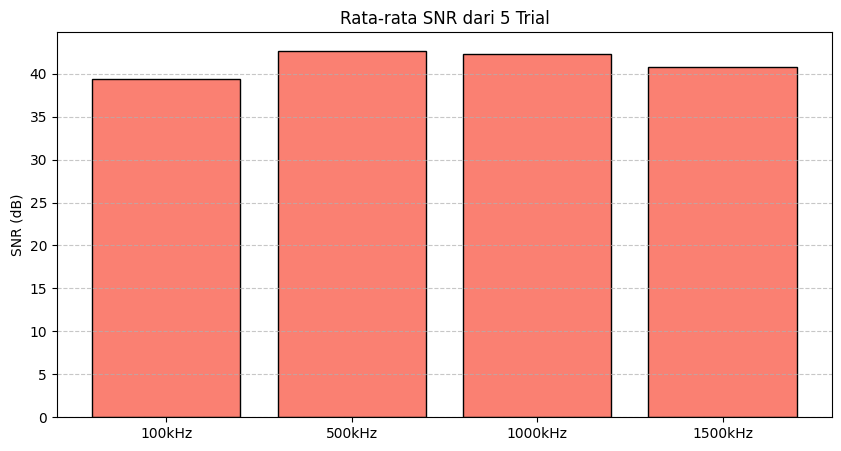

In [20]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. KONFIGURASI
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_1.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_2.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_3.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_4.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan\breast_udara_12ch_5.dat'
]

OUTPUT_FOLDER = r'C:\Users\ASUS\Desktop\Analisis_Gabungan_5_Trial'
THRESHOLD_DEADZONE = 4.1 
TARGET_FREQS = ['100kHz', '500kHz', '1000kHz', '1500kHz']
SIGMA_SYSTEM = 0.3146 # Nilai estimasi noise alat (mV)

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# 2. PROSES LOADING & PERHITUNGAN INDIVIDUAL
all_stats_collector = [] 

print("--- MEMULAI PROSES GABUNGAN 5 TRIAL ---")

for f_idx, path in enumerate(FILE_PATHS):
    try:
        mat = scipy.io.loadmat(path)
        freqs_raw = mat['LS_FREQS'].flatten()
        ve_mean = np.mean(mat['Ve_kalibrasi'], axis=1)
        vf_mean = np.mean(mat['Vf_kalibrasi'], axis=1)
        vr_mean = np.mean(mat['Vr_all'], axis=1)
        
        trial_results = {}
        for idx, f in enumerate(freqs_raw):
            f_label = f"{f}kHz"
            if f_label not in TARGET_FREQS: continue
            
            gap = vf_mean[:, idx] - ve_mean[:, idx]
            is_alive = gap > THRESHOLD_DEADZONE
            
            # Hitung SNR (Voltage Domain) agar selaras dengan file tunggal
            signal_power = np.mean(gap[is_alive]) if np.any(is_alive) else 0
            snr_db = 20 * np.log10(signal_power / SIGMA_SYSTEM) if signal_power > 0 else 0
            
            # Normalisasi Kapasitansi
            c_norm = np.zeros(len(gap))
            c_norm[is_alive] = (vr_mean[is_alive, idx] - ve_mean[is_alive, idx]) / gap[is_alive]
            c_norm = np.clip(c_norm, 0, 1)
            
            trial_results[f_label] = {
                'snr': snr_db,
                'peak': np.max(c_norm),
                'dead_zones': np.sum(~is_alive)
            }
        
        all_stats_collector.append(trial_results)
        print(f"Trial {f_idx+1} sukses diproses.")

    except Exception as e:
        print(f"Error pada Trial {f_idx+1}: {e}")

# 3. AGREGASI (RATA-RATA DARI 5 TRIAL)
final_summary = []

for f_label in TARGET_FREQS:
    # Kumpulkan data dari 5 trial untuk frekuensi yang sama
    snr_list = [t[f_label]['snr'] for t in all_stats_collector if f_label in t]
    peak_list = [t[f_label]['peak'] for t in all_stats_collector if f_label in t]
    dz_list = [t[f_label]['dead_zones'] for t in all_stats_collector if f_label in t]
    
    avg_peak = np.mean(peak_list)
    std_peak = np.std(peak_list) # Mengukur stabilitas/presisi
    rsd_peak = (std_peak / avg_peak) * 100 if avg_peak > 0 else 0
    
    final_summary.append({
        'Frequency': f_label,
        'Peak_Mean': round(avg_peak, 4),
        'Peak_Std': round(std_peak, 4),
        'RSD_%': round(rsd_peak, 2), # Semakin kecil RSD, sistem semakin stabil
        'SNR_Avg': round(np.mean(snr_list), 2),
        'Dead_Zones_Avg': int(round(np.mean(dz_list)))
    })

df_final = pd.DataFrame(final_summary)

# 4. OUTPUT HASIL
print("\n=== FINAL AGGREGATED SUMMARY (5 TRIALS) ===")
print(df_final.to_string(index=False))

# 5. ANALISIS FREKUENSI OPTIMAL
optimal_row = df_final.loc[df_final['Dead_Zones_Avg'].idxmin()]
print(f"\nKesimpulan Frekuensi Optimal: {optimal_row['Frequency']}")
print(f"Alasan: Memiliki rata-rata Dead Zone terendah ({optimal_row['Dead_Zones_Avg']}) dan SNR stabil ({optimal_row['SNR_Avg']} dB).")

# Visualisasi Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(df_final['Frequency'], df_final['SNR_Avg'], color='salmon', edgecolor='black')
plt.title('Rata-rata SNR dari 5 Trial')
plt.ylabel('SNR (dB)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

analisis data gabungan (STD akurat)

In [22]:
import scipy.io
import numpy as np
import pandas as pd
import os  # Tambahkan ini

# 1. KONFIGURASI
# Hapus backslash terakhir di dalam string
FOLDER_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan'
FILE_NAMES = ['breast_udara_12ch_1.dat', 'breast_udara_12ch_2.dat', 'breast_udara_12ch_3.dat', 'breast_udara_12ch_4.dat', 'breast_udara_12ch_5.dat']
TARGET_FREQS = ['100kHz', '500kHz', '1000kHz', '1500kHz']
THRESHOLD_DEADZONE = 4.1

def hitung_snr_temporal(file_path):
    # Cek apakah file benar-benar ada sebelum dibuka
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return None

    mat_data = scipy.io.loadmat(file_path)
    freqs_raw = mat_data['LS_FREQS'].flatten()
    vr_all = mat_data['Vr_all']
    ve_mean = np.mean(mat_data['Ve_kalibrasi'], axis=1)
    vf_mean = np.mean(mat_data['Vf_kalibrasi'], axis=1)
    
    snr_per_freq = {}
    for idx, f in enumerate(freqs_raw):
        f_label = f"{f}kHz"
        if f_label not in TARGET_FREQS: continue
        
        gap = vf_mean[:, idx] - ve_mean[:, idx]
        mask_alive = gap > THRESHOLD_DEADZONE
        
        sig_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
        
        # Noise dari fluktuasi frame
        std_elektroda = np.std(vr_all[:, :, idx], axis=1)
        noise_temp = np.mean(std_elektroda[mask_alive]) if np.any(mask_alive) else 1e-5
        
        snr_db = 20 * np.log10(sig_mean / noise_temp) if sig_mean > 0 else 0
        snr_per_freq[f_label] = snr_db
    return snr_per_freq

# 2. PROSES SEMUA TRIAL
all_trials_data = []
for file in FILE_NAMES:
    # Gunakan os.path.join agar alamat file terbentuk sempurna
    path = os.path.join(FOLDER_PATH, file)
    res = hitung_snr_temporal(path)
    if res:
        all_trials_data.append(res)

# 3. REKAPITULASI
if all_trials_data:
    final_stats = []
    for f_label in TARGET_FREQS:
        snr_values = [trial[f_label] for trial in all_trials_data]
        
        final_stats.append({
            'Frequency': f_label,
            'SNR_Avg (dB)': round(np.mean(snr_values), 2),
            'SNR_Std (Stabilitas)': round(np.std(snr_values), 3),
            'Min_SNR': round(np.min(snr_values), 2),
            'Max_SNR': round(np.max(snr_values), 2)
        })

    df_final = pd.DataFrame(final_stats)
    print("\n=== REKAP SNR GABUNGAN (METODE TEMPORAL) ===")
    print(df_final.to_string(index=False))
else:
    print("Tidak ada data yang berhasil diproses.")


=== REKAP SNR GABUNGAN (METODE TEMPORAL) ===
Frequency  SNR_Avg (dB)  SNR_Std (Stabilitas)  Min_SNR  Max_SNR
   100kHz         35.82                 0.289    35.36    36.24
   500kHz         28.38                 0.032    28.34    28.43
  1000kHz         25.55                 0.020    25.52    25.58
  1500kHz          9.76                 0.004     9.75     9.76


analisis data gabungan lengkap


TABEL DETAIL PER TRIAL (KOMPONEN PENYUSUN SNR)

>>> HASIL PENGAMBILAN DATA: T1 (breast_udara_12ch_1.dat)
Frequency  Signal_Mean(mV)  Noise_Temp(mV)  SNR(dB)
   100kHz          29.3510        0.471395    35.88
   500kHz          42.8984        1.625613    28.43
  1000kHz          40.8267        2.161976    25.52
  1500kHz          34.5067       11.215960     9.76
--------------------------------------------------

>>> HASIL PENGAMBILAN DATA: T2 (breast_udara_12ch_2.dat)
Frequency  Signal_Mean(mV)  Noise_Temp(mV)  SNR(dB)
   100kHz          29.3510        0.481916    35.69
   500kHz          42.8984        1.629133    28.41
  1000kHz          40.8267        2.158530    25.54
  1500kHz          34.5067       11.215314     9.76
--------------------------------------------------

>>> HASIL PENGAMBILAN DATA: T3 (breast_udara_12ch_3.dat)
Frequency  Signal_Mean(mV)  Noise_Temp(mV)  SNR(dB)
   100kHz          29.3510        0.500849    35.36
   500kHz          42.8984        1.635023    28.38


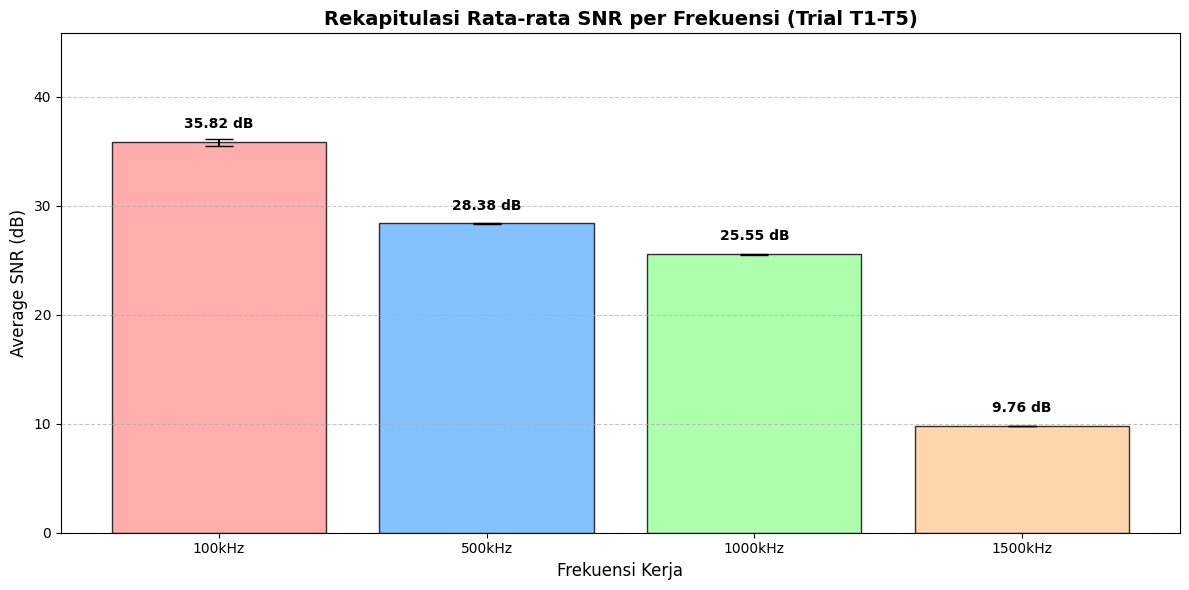

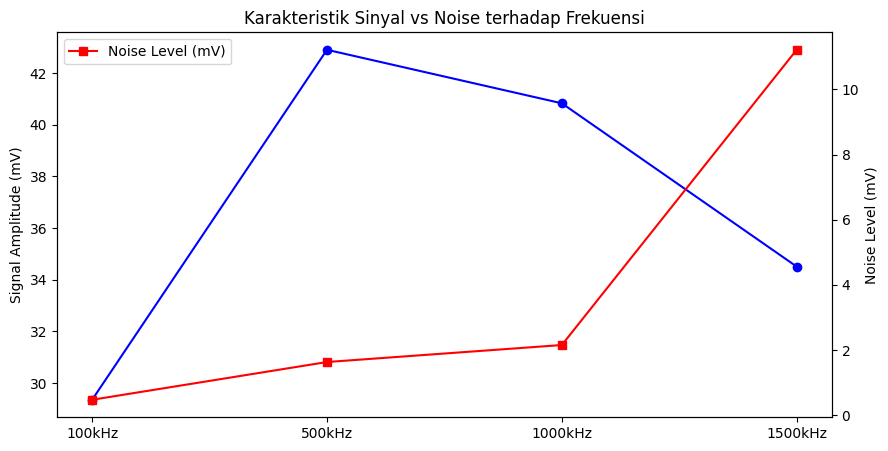

In [25]:
import scipy.io
import numpy as np
import pandas as pd
import os

# 1. KONFIGURASI
FOLDER_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\3. 12ch Das 4\objek_udara_01_23 Jan'
FILE_NAMES = ['breast_udara_12ch_1.dat', 'breast_udara_12ch_2.dat', 'breast_udara_12ch_3.dat', 'breast_udara_12ch_4.dat', 'breast_udara_12ch_5.dat']
TARGET_FREQS = ['100kHz', '500kHz', '1000kHz', '1500kHz']
THRESHOLD_DEADZONE = 4.1

def ambil_data_detail(file_path, trial_name):
    if not os.path.exists(file_path):
        return None
    
    mat_data = scipy.io.loadmat(file_path)
    freqs_raw = mat_data['LS_FREQS'].flatten()
    vr_all = mat_data['Vr_all']
    ve_mean = np.mean(mat_data['Ve_kalibrasi'], axis=1)
    vf_mean = np.mean(mat_data['Vf_kalibrasi'], axis=1)
    
    trial_results = []
    for idx, f in enumerate(freqs_raw):
        f_label = f"{f}kHz"
        if f_label not in TARGET_FREQS: continue
        
        gap = vf_mean[:, idx] - ve_mean[:, idx]
        mask_alive = gap > THRESHOLD_DEADZONE
        
        sig_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
        noise_temp = np.mean(np.std(vr_all[:, :, idx], axis=1)[mask_alive]) if np.any(mask_alive) else 1e-5
        snr_db = 20 * np.log10(sig_mean / noise_temp) if sig_mean > 0 else 0
        
        trial_results.append({
            'Trial': trial_name,
            'Frequency': f_label,
            'Signal_Mean(mV)': round(sig_mean, 4),
            'Noise_Temp(mV)': round(noise_temp, 6),
            'SNR(dB)': round(snr_db, 2)
        })
    return trial_results

# 2. PROSES DATA
all_rows = []
print("\n" + "="*70)
print("TABEL DETAIL PER TRIAL (KOMPONEN PENYUSUN SNR)")
print("="*70)

for i, file in enumerate(FILE_NAMES):
    path = os.path.join(FOLDER_PATH, file)
    trial_name = f"T{i+1}"
    data = ambil_data_detail(path, trial_name)
    
    if data:
        all_rows.extend(data)
        # Menampilkan tabel per trial secara terpisah
        df_temp = pd.DataFrame(data)
        print(f"\n>>> HASIL PENGAMBILAN DATA: {trial_name} ({file})")
        print(df_temp.drop(columns=['Trial']).to_string(index=False)) # Drop kolom 'Trial' agar rapi karena sudah ada di judul
        print("-" * 50)

# 3. TAMPILKAN TABEL REKAP (Hasil Akhir Gabungan)
df_all = pd.DataFrame(all_rows)
rekap_rows = []
for f_label in TARGET_FREQS:
    subset = df_all[df_all['Frequency'] == f_label]
    rekap_rows.append({
        'Frequency': f_label,
        'Avg_Signal(mV)': round(subset['Signal_Mean(mV)'].mean(), 4),
        'Avg_Noise(mV)': round(subset['Noise_Temp(mV)'].mean(), 6),
        'Avg_SNR(dB)': round(subset['SNR(dB)'].mean(), 2),
        'SNR_Std': round(subset['SNR(dB)'].std(), 3)
    })

df_rekap = pd.DataFrame(rekap_rows)
print("\n" + "="*70)
print("TABEL REKAPITULASI SNR GABUNGAN (FINAL)")
print("="*70)
print(df_rekap.to_string(index=False))
print("="*70)

import matplotlib.pyplot as plt

# --- 4. VISUALISASI HASIL REKAP ---
plt.figure(figsize=(12, 6))

# Warna untuk estetika
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

# Membuat Bar Chart untuk Avg_SNR
bars = plt.bar(df_rekap['Frequency'], df_rekap['Avg_SNR(dB)'], 
               yerr=df_rekap['SNR_Std'], # Menampilkan Standard Deviasi sebagai Error Bar
               capsize=10, color=colors, edgecolor='black', alpha=0.8)

# Menambahkan Label Angka di Atas Bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f} dB', 
             ha='center', va='bottom', fontweight='bold')

plt.title('Rekapitulasi Rata-rata SNR per Frekuensi (Trial T1-T5)', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Kerja', fontsize=12)
plt.ylabel('Average SNR (dB)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df_rekap['Avg_SNR(dB)'].max() + 10) # Memberi ruang di atas untuk label

plt.tight_layout()
plt.show()

# --- 5. GRAFIK TREN NOISE VS SIGNAL (OPSIONAL) ---
plt.figure(figsize=(10, 5))
plt.plot(df_rekap['Frequency'], df_rekap['Avg_Signal(mV)'], marker='o', label='Signal Mean (mV)', color='blue')
plt.ylabel('Signal Amplitude (mV)')
plt.twinx() # Membuat sumbu Y kedua untuk Noise
plt.plot(df_rekap['Frequency'], df_rekap['Avg_Noise(mV)'], marker='s', label='Noise Level (mV)', color='red')
plt.ylabel('Noise Level (mV)')
plt.title('Karakteristik Sinyal vs Noise terhadap Frekuensi')
plt.legend(loc='upper left')
plt.show()